# Speculative Decoding: Fast Autoregressive Inference

This notebook explores **Speculative Decoding**, a powerful technique that accelerates LLM inference by using a small draft model to propose multiple tokens that are then verified in parallel by the larger target model.

**What you'll learn:**
- Why autoregressive generation is slow (memory-bound, sequential)
- The speculative decoding algorithm and why it works
- How parallel verification achieves speedup without changing outputs
- Implementing speculative decoding from scratch
- Acceptance rate analysis and expected speedup
- Draft model selection strategies


## Setup


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import time
from aiml_notebooks import get_device, set_seed

# Set style and seed for reproducibility
sns.set_style('whitegrid')
set_seed(42)
device = get_device()


Using CUDA GPU: NVIDIA GeForce RTX 4090


## Part 1: The Autoregressive Bottleneck

### Why is LLM Inference Slow?

Autoregressive language models generate text **one token at a time**:

1. Input: "The quick brown"
2. Model predicts: "fox"
3. Input: "The quick brown fox"
4. Model predicts: "jumps"
5. ... and so on

Each step requires a **full forward pass** through the model. For a model like LLaMA-70B:
- 70 billion parameters to load from memory
- Memory bandwidth is the bottleneck (not compute!)
- Each token takes roughly the same time regardless of batch size

**Key insight**: The model could verify 10 tokens as fast as generating 1, because:
- Verification = one forward pass with multiple tokens
- Generation = one forward pass per token
- Both are memory-bandwidth bound, not compute bound


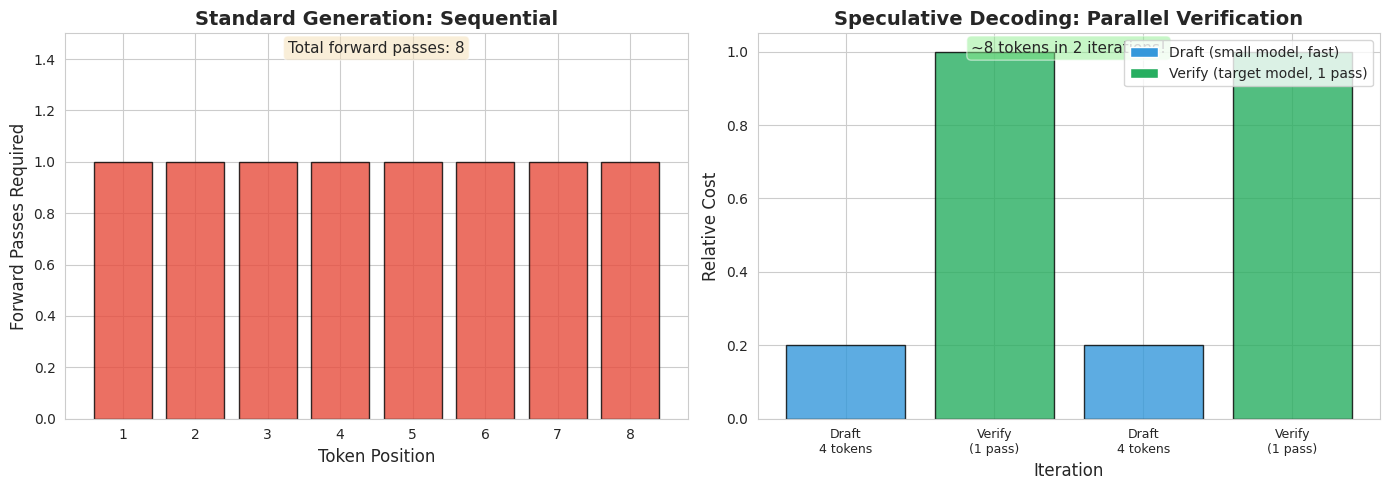

Key insight: Verification is almost as fast as single token generation!
This is because both are memory-bandwidth bound, not compute bound.


In [2]:
# Visualize the autoregressive bottleneck
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Standard autoregressive generation
ax1 = axes[0]
n_tokens = 8
steps = range(1, n_tokens + 1)

# Each token requires a full forward pass
forward_passes = list(steps)  # 1 forward pass per token

ax1.bar(steps, [1]*n_tokens, color='#e74c3c', edgecolor='black', alpha=0.8)
ax1.set_xlabel('Token Position', fontsize=12)
ax1.set_ylabel('Forward Passes Required', fontsize=12)
ax1.set_title('Standard Generation: Sequential', fontsize=14, fontweight='bold')
ax1.set_xticks(steps)
ax1.set_ylim(0, 1.5)
total_standard = n_tokens
ax1.annotate(f'Total forward passes: {total_standard}', xy=(0.5, 0.95), 
             xycoords='axes fraction', fontsize=11, ha='center',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Right: Speculative decoding
ax2 = axes[1]
draft_tokens = 4  # Draft model proposes 4 tokens
accept_rate = 0.75  # 75% acceptance rate

# Speculative: draft (cheap) + verify (1 forward pass for all)
colors = ['#3498db'] + ['#27ae60'] * (n_tokens - 1)
heights = [0.3] + [0.1] * 3 + [1.0] + [0.1] * 3  # Draft is cheap, verify is one pass

# Simplified view: show iterations
iterations = ['Draft\n4 tokens', 'Verify\n(1 pass)', 'Draft\n4 tokens', 'Verify\n(1 pass)']
iter_heights = [0.2, 1.0, 0.2, 1.0]
iter_colors = ['#3498db', '#27ae60', '#3498db', '#27ae60']

bars = ax2.bar(range(1, 5), iter_heights, color=iter_colors, edgecolor='black', alpha=0.8)
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Relative Cost', fontsize=12)
ax2.set_title('Speculative Decoding: Parallel Verification', fontsize=14, fontweight='bold')
ax2.set_xticks(range(1, 5))
ax2.set_xticklabels(iterations, fontsize=9)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='Draft (small model, fast)'),
                   Patch(facecolor='#27ae60', label='Verify (target model, 1 pass)')]
ax2.legend(handles=legend_elements, loc='upper right', fontsize=10)

ax2.annotate(f'~{n_tokens} tokens in 2 iterations!', xy=(0.5, 0.95), 
             xycoords='axes fraction', fontsize=11, ha='center',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.show()

print("Key insight: Verification is almost as fast as single token generation!")
print("This is because both are memory-bandwidth bound, not compute bound.")


### Memory Bandwidth vs Compute

Modern LLMs during inference are **memory-bandwidth bound**:

| Metric | Value (A100 GPU) |
|--------|------------------|
| Memory Bandwidth | 2 TB/s |
| Compute (FP16) | 312 TFLOPS |
| LLaMA-70B Parameters | 140 GB (FP16) |
| Time to load model | ~70 ms |
| FLOPs per token | ~140 GFLOPs |
| Compute time per token | ~0.5 ms |

**Memory loading (70ms) >> Compute (0.5ms)**

This means:
- Processing 1 token ≈ Processing 10 tokens (both load entire model once)
- Generating 10 tokens = 10 forward passes = 10× slower
- Verifying 10 tokens = 1 forward pass = same speed!


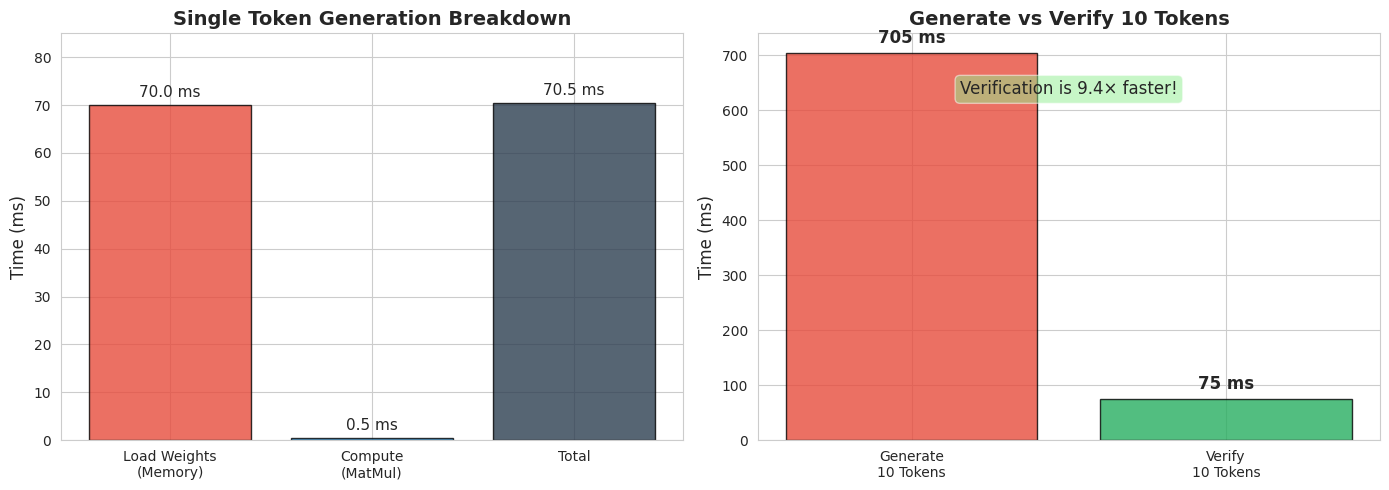

Generate 10 tokens sequentially: 705 ms
Verify 10 tokens in parallel: 75 ms
Potential speedup: 9.4×


In [3]:
# Visualize why verification is "free"
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Time breakdown for single token generation
ax1 = axes[0]
components = ['Load Weights\n(Memory)', 'Compute\n(MatMul)', 'Total']
single_token_times = [70, 0.5, 70.5]  # ms
colors = ['#e74c3c', '#3498db', '#2c3e50']

bars = ax1.bar(components, single_token_times, color=colors, edgecolor='black', alpha=0.8)
ax1.set_ylabel('Time (ms)', fontsize=12)
ax1.set_title('Single Token Generation Breakdown', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 85)

for bar, time_val in zip(bars, single_token_times):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{time_val:.1f} ms', ha='center', va='bottom', fontsize=11)

# Right: Compare generating vs verifying 10 tokens
ax2 = axes[1]
scenarios = ['Generate\n10 Tokens', 'Verify\n10 Tokens']

# Generate 10 tokens: 10 × (70 + 0.5) = 705 ms
# Verify 10 tokens: 70 + 10 × 0.5 = 75 ms
generate_time = 10 * 70.5
verify_time = 70 + 10 * 0.5
times = [generate_time, verify_time]

bars = ax2.bar(scenarios, times, color=['#e74c3c', '#27ae60'], edgecolor='black', alpha=0.8)
ax2.set_ylabel('Time (ms)', fontsize=12)
ax2.set_title('Generate vs Verify 10 Tokens', fontsize=14, fontweight='bold')

for bar, t in zip(bars, times):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{t:.0f} ms', ha='center', va='bottom', fontsize=12, fontweight='bold')

speedup = generate_time / verify_time
ax2.annotate(f'Verification is {speedup:.1f}× faster!', xy=(0.5, 0.85), 
             xycoords='axes fraction', fontsize=12, ha='center',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"Generate 10 tokens sequentially: {generate_time:.0f} ms")
print(f"Verify 10 tokens in parallel: {verify_time:.0f} ms")
print(f"Potential speedup: {speedup:.1f}×")


## Part 2: The Speculative Decoding Algorithm

### Core Idea

Speculative decoding uses two models:
1. **Draft model** ($M_q$): Small, fast model that proposes candidate tokens
2. **Target model** ($M_p$): Large, accurate model that verifies candidates

### Algorithm

```
for each iteration:
    1. Draft model generates K candidate tokens autoregressively
    2. Target model scores all K+1 positions in ONE forward pass
    3. Accept tokens from left to right until first rejection
    4. Sample a correction token from adjusted distribution
    5. Continue from the last accepted position
```

### Why This Works

- Draft model is fast (small) → generating K tokens is cheap
- Target model verification is parallel → scoring K tokens ≈ scoring 1 token
- If acceptance rate is high → significant speedup
- Output distribution is **exactly** the same as target model!


## Part 3: The Rejection Sampling Scheme

### Acceptance Criterion

For each draft token $x$ proposed by draft model $q$ at position $t$:

1. Compute acceptance probability: $\min\left(1, \frac{p(x)}{q(x)}\right)$
2. Accept with this probability
3. If rejected, sample from adjusted distribution: $\text{norm}(\max(0, p(x) - q(x)))$

Where:
- $p(x)$ = target model probability for token $x$
- $q(x)$ = draft model probability for token $x$

### Why This Preserves the Target Distribution

This is a form of **rejection sampling** that guarantees:
- If draft matches target well: high acceptance, fast generation
- If draft differs from target: rejection + correction from target
- **Final output distribution = target distribution exactly!**


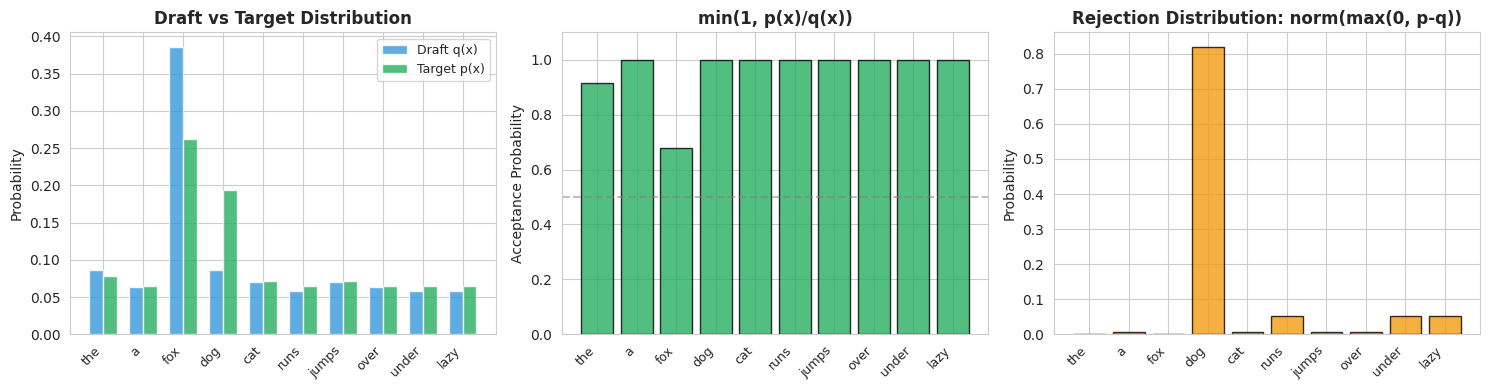


Simulating 1000 samples:
Draft token 'fox' accepted: 68.2%
Theoretical acceptance: 67.8%


In [4]:
def speculative_sampling_step(draft_probs, target_probs, draft_token_idx):
    """
    Perform one step of speculative sampling.
    
    Args:
        draft_probs: Distribution from draft model (vocab_size,)
        target_probs: Distribution from target model (vocab_size,)
        draft_token_idx: Token sampled from draft model
        
    Returns:
        accepted: Whether the draft token was accepted
        token_idx: Final token (draft if accepted, resampled if rejected)
    """
    # Get probabilities for the draft token
    q_x = draft_probs[draft_token_idx]
    p_x = target_probs[draft_token_idx]
    
    # Acceptance probability
    accept_prob = min(1.0, p_x / q_x)
    
    # Sample acceptance
    if torch.rand(1).item() < accept_prob:
        return True, draft_token_idx
    else:
        # Rejection: sample from adjusted distribution
        # adjusted = norm(max(0, p - q))
        adjusted = torch.clamp(target_probs - draft_probs, min=0)
        adjusted = adjusted / adjusted.sum()  # Normalize
        new_token = torch.multinomial(adjusted, 1).item()
        return False, new_token

# Demonstrate with a simple example
vocab_size = 10
vocab = ['the', 'a', 'fox', 'dog', 'cat', 'runs', 'jumps', 'over', 'under', 'lazy']

# Create example distributions
# Draft model thinks "fox" is most likely
draft_probs = torch.softmax(torch.tensor([0.5, 0.2, 2.0, 0.5, 0.3, 0.1, 0.3, 0.2, 0.1, 0.1]), dim=0)
# Target model also thinks "fox" is likely, but gives more mass to "dog"
target_probs = torch.softmax(torch.tensor([0.3, 0.1, 1.5, 1.2, 0.2, 0.1, 0.2, 0.1, 0.1, 0.1]), dim=0)

# Visualize the distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

x = np.arange(vocab_size)
width = 0.35

# Left: Both distributions
ax1 = axes[0]
ax1.bar(x - width/2, draft_probs.numpy(), width, label='Draft q(x)', color='#3498db', alpha=0.8)
ax1.bar(x + width/2, target_probs.numpy(), width, label='Target p(x)', color='#27ae60', alpha=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(vocab, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Probability', fontsize=10)
ax1.set_title('Draft vs Target Distribution', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)

# Middle: Acceptance probability
ax2 = axes[1]
accept_probs = torch.minimum(torch.ones_like(draft_probs), target_probs / draft_probs)
colors = ['#27ae60' if p > 0.5 else '#e74c3c' for p in accept_probs]
ax2.bar(x, accept_probs.numpy(), color=colors, alpha=0.8, edgecolor='black')
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax2.set_xticks(x)
ax2.set_xticklabels(vocab, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Acceptance Probability', fontsize=10)
ax2.set_title('min(1, p(x)/q(x))', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1.1)

# Right: Adjusted distribution for rejection
ax3 = axes[2]
adjusted = torch.clamp(target_probs - draft_probs, min=0)
adjusted = adjusted / adjusted.sum()
ax3.bar(x, adjusted.numpy(), color='#f39c12', alpha=0.8, edgecolor='black')
ax3.set_xticks(x)
ax3.set_xticklabels(vocab, rotation=45, ha='right', fontsize=9)
ax3.set_ylabel('Probability', fontsize=10)
ax3.set_title('Rejection Distribution: norm(max(0, p-q))', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Simulate sampling
print("\nSimulating 1000 samples:")
draft_token = 2  # "fox" - most likely under draft
accept_count = 0
token_counts = torch.zeros(vocab_size)

for _ in range(1000):
    accepted, token = speculative_sampling_step(draft_probs, target_probs, draft_token)
    if accepted:
        accept_count += 1
    token_counts[token] += 1

print(f"Draft token 'fox' accepted: {accept_count/10:.1f}%")
print(f"Theoretical acceptance: {accept_probs[draft_token].item()*100:.1f}%")


### Proof: Output Matches Target Distribution

Let's verify empirically that speculative sampling produces the target distribution.

For any token $x$, the probability of outputting $x$ is:

$$P(\text{output } x) = q(x) \cdot \min\left(1, \frac{p(x)}{q(x)}\right) + \sum_{x' \neq x} q(x') \cdot \left(1 - \min\left(1, \frac{p(x')}{q(x')}\right)\right) \cdot \frac{\max(0, p(x) - q(x))}{\sum_y \max(0, p(y) - q(y))}$$

This simplifies to $p(x)$ — the target distribution!


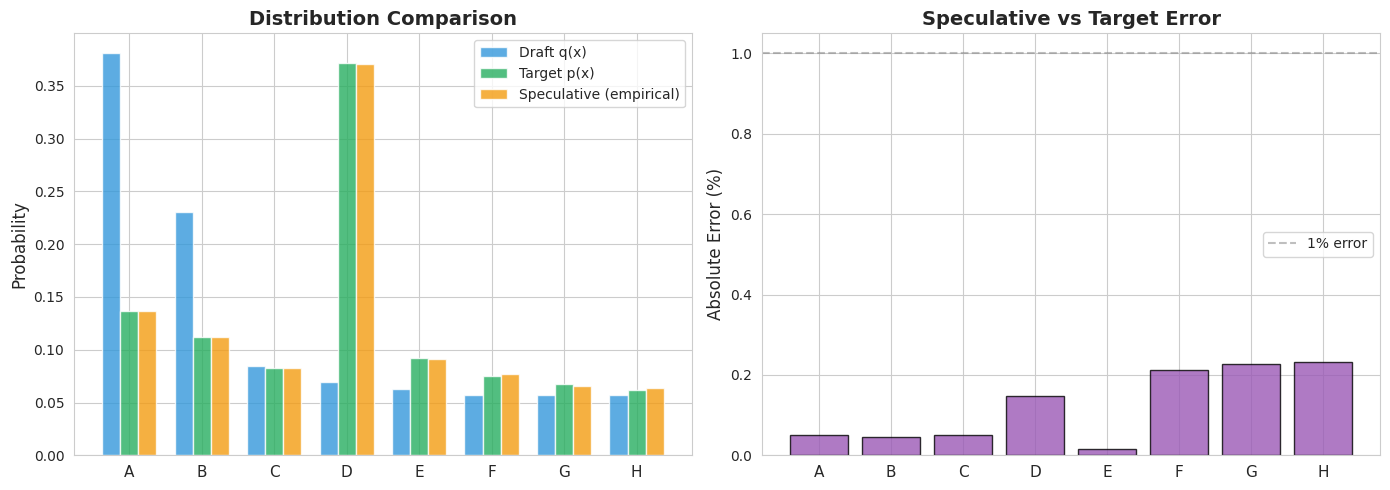

Maximum absolute error: 0.23%
KL divergence: 0.000117

✓ Speculative sampling produces the target distribution!


In [5]:
def speculative_sample_full(draft_probs, target_probs, n_samples=10000):
    """
    Sample from speculative decoding scheme and compare to target.
    """
    vocab_size = len(draft_probs)
    output_counts = torch.zeros(vocab_size)
    
    for _ in range(n_samples):
        # First, sample from draft
        draft_token = torch.multinomial(draft_probs, 1).item()
        
        # Then, apply speculative sampling
        accepted, final_token = speculative_sampling_step(draft_probs, target_probs, draft_token)
        output_counts[final_token] += 1
    
    return output_counts / n_samples

# Create more diverse distributions
vocab_size = 8
vocab = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

# Draft: concentrated on A and B
draft_probs = torch.softmax(torch.tensor([2.0, 1.5, 0.5, 0.3, 0.2, 0.1, 0.1, 0.1]), dim=0)
# Target: more uniform, prefers D
target_probs = torch.softmax(torch.tensor([1.0, 0.8, 0.5, 2.0, 0.6, 0.4, 0.3, 0.2]), dim=0)

# Sample
empirical_probs = speculative_sample_full(draft_probs, target_probs, n_samples=50000)

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(vocab_size)
width = 0.25

# Left: All three distributions
ax1 = axes[0]
ax1.bar(x - width, draft_probs.numpy(), width, label='Draft q(x)', color='#3498db', alpha=0.8)
ax1.bar(x, target_probs.numpy(), width, label='Target p(x)', color='#27ae60', alpha=0.8)
ax1.bar(x + width, empirical_probs.numpy(), width, label='Speculative (empirical)', color='#f39c12', alpha=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(vocab, fontsize=11)
ax1.set_ylabel('Probability', fontsize=12)
ax1.set_title('Distribution Comparison', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)

# Right: Error between empirical and target
ax2 = axes[1]
error = (empirical_probs - target_probs).abs().numpy()
ax2.bar(x, error * 100, color='#9b59b6', alpha=0.8, edgecolor='black')
ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='1% error')
ax2.set_xticks(x)
ax2.set_xticklabels(vocab, fontsize=11)
ax2.set_ylabel('Absolute Error (%)', fontsize=12)
ax2.set_title('Speculative vs Target Error', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.show()

# Calculate KL divergence
kl_div = F.kl_div(empirical_probs.log(), target_probs, reduction='sum').item()
max_error = error.max() * 100

print(f"Maximum absolute error: {max_error:.2f}%")
print(f"KL divergence: {kl_div:.6f}")
print(f"\n✓ Speculative sampling produces the target distribution!")


## Part 4: Implementing Speculative Decoding from Scratch

Let's implement a complete speculative decoding system with simple transformer models.


In [6]:
class SimpleTransformer(nn.Module):
    """
    Simple transformer decoder for demonstration.
    """
    def __init__(self, vocab_size, d_model, n_heads, n_layers, max_seq_len=512):
        super().__init__()
        self.d_model = d_model
        self.vocab_size = vocab_size
        
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_seq_len, d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=n_heads,
            dim_feedforward=4*d_model,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        
        self.ln_f = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        
        # Causal mask
        self.register_buffer(
            'causal_mask',
            torch.triu(torch.ones(max_seq_len, max_seq_len) * float('-inf'), diagonal=1)
        )
        
    def forward(self, input_ids):
        """
        Forward pass.
        
        Args:
            input_ids: Token IDs (batch, seq_len)
            
        Returns:
            logits: (batch, seq_len, vocab_size)
        """
        batch_size, seq_len = input_ids.shape
        
        positions = torch.arange(seq_len, device=input_ids.device)
        x = self.token_emb(input_ids) + self.pos_emb(positions)
        
        mask = self.causal_mask[:seq_len, :seq_len]
        x = self.transformer(x, mask=mask)
        
        x = self.ln_f(x)
        logits = self.lm_head(x)
        
        return logits

print("SimpleTransformer defined!")


SimpleTransformer defined!


In [7]:
@torch.no_grad()
def standard_generate(model, prompt_ids, max_new_tokens, temperature=1.0):
    """
    Standard autoregressive generation (baseline).
    """
    model.eval()
    generated = prompt_ids.clone()
    
    for _ in range(max_new_tokens):
        logits = model(generated)
        next_token_logits = logits[:, -1, :] / temperature
        probs = F.softmax(next_token_logits, dim=-1)
        next_token = torch.multinomial(probs, 1)
        generated = torch.cat([generated, next_token], dim=1)
    
    return generated


@torch.no_grad()
def speculative_decode(
    target_model,
    draft_model,
    prompt_ids,
    max_new_tokens,
    gamma=4,  # Number of draft tokens per iteration
    temperature=1.0
):
    """
    Speculative decoding with draft and target models.
    
    Args:
        target_model: Large, accurate model (M_p)
        draft_model: Small, fast model (M_q)
        prompt_ids: Input token IDs (batch_size, prompt_len)
        max_new_tokens: Maximum tokens to generate
        gamma: Number of draft tokens per speculation step
        temperature: Sampling temperature
        
    Returns:
        generated: Generated token IDs
        stats: Dictionary with generation statistics
    """
    target_model.eval()
    draft_model.eval()
    
    generated = prompt_ids.clone()
    total_draft_tokens = 0
    total_accepted = 0
    n_target_calls = 0
    n_draft_calls = 0
    tokens_generated = 0
    
    while tokens_generated < max_new_tokens:
        # Step 1: Generate gamma draft tokens autoregressively
        draft_tokens = []
        draft_probs_list = []
        current_seq = generated.clone()
        
        for _ in range(gamma):
            # Get draft model prediction
            draft_logits = draft_model(current_seq)
            draft_probs = F.softmax(draft_logits[:, -1, :] / temperature, dim=-1)
            
            # Sample from draft
            draft_token = torch.multinomial(draft_probs, 1)
            draft_tokens.append(draft_token)
            draft_probs_list.append(draft_probs)
            
            # Append to sequence for next draft token
            current_seq = torch.cat([current_seq, draft_token], dim=1)
            n_draft_calls += 1
        
        total_draft_tokens += gamma
        
        # Step 2: Verify all draft tokens with target model (single forward pass!)
        # We need to get target probs for positions: len(generated) to len(generated)+gamma
        target_logits = target_model(current_seq)
        n_target_calls += 1
        
        # Extract target probabilities for verification
        # target_logits[:, i, :] gives logits for predicting token at position i+1
        prompt_len = generated.shape[1]
        
        # Step 3: Accept/reject draft tokens
        n_accepted = 0
        for i in range(gamma):
            # Position in the sequence
            pos = prompt_len + i - 1  # -1 because logits[pos] predicts token at pos+1
            
            # Get probabilities
            target_probs = F.softmax(target_logits[:, pos, :] / temperature, dim=-1)
            draft_prob = draft_probs_list[i]
            draft_token = draft_tokens[i]
            
            # Get probability of the draft token under both models
            draft_token_idx = draft_token.item()
            q_x = draft_prob[0, draft_token_idx].item()
            p_x = target_probs[0, draft_token_idx].item()
            
            # Acceptance probability
            accept_prob = min(1.0, p_x / (q_x + 1e-10))
            
            # Sample acceptance
            if torch.rand(1).item() < accept_prob:
                # Accept this token
                n_accepted += 1
                generated = torch.cat([generated, draft_token], dim=1)
                tokens_generated += 1
                
                if tokens_generated >= max_new_tokens:
                    break
            else:
                # Reject: sample from adjusted distribution
                adjusted = torch.clamp(target_probs - draft_prob, min=0)
                adjusted = adjusted / (adjusted.sum() + 1e-10)
                
                # Sample correction token
                correction_token = torch.multinomial(adjusted, 1)
                generated = torch.cat([generated, correction_token], dim=1)
                tokens_generated += 1
                break  # Stop accepting after first rejection
        
        # If all draft tokens accepted, sample one more from target
        if n_accepted == gamma and tokens_generated < max_new_tokens:
            # Sample from target at the last position
            final_probs = F.softmax(target_logits[:, -1, :] / temperature, dim=-1)
            final_token = torch.multinomial(final_probs, 1)
            generated = torch.cat([generated, final_token], dim=1)
            tokens_generated += 1
        
        total_accepted += n_accepted
    
    stats = {
        'total_draft_tokens': total_draft_tokens,
        'total_accepted': total_accepted,
        'acceptance_rate': total_accepted / total_draft_tokens if total_draft_tokens > 0 else 0,
        'n_target_calls': n_target_calls,
        'n_draft_calls': n_draft_calls,
        'tokens_generated': tokens_generated
    }
    
    return generated, stats

print("Speculative decoding implementation ready!")


Speculative decoding implementation ready!


In [8]:
# Create target and draft models
vocab_size = 1000
max_seq_len = 256

# Target model: larger
target_model = SimpleTransformer(
    vocab_size=vocab_size,
    d_model=256,
    n_heads=8,
    n_layers=6,
    max_seq_len=max_seq_len
).to(device)

# Draft model: smaller (but trained to mimic target - in practice)
draft_model = SimpleTransformer(
    vocab_size=vocab_size,
    d_model=128,
    n_heads=4,
    n_layers=2,
    max_seq_len=max_seq_len
).to(device)

# Count parameters
target_params = sum(p.numel() for p in target_model.parameters())
draft_params = sum(p.numel() for p in draft_model.parameters())

print(f"Target model parameters: {target_params:,}")
print(f"Draft model parameters: {draft_params:,}")
print(f"Draft is {target_params/draft_params:.1f}× smaller than target")


Target model parameters: 5,316,608
Draft model parameters: 685,568
Draft is 7.8× smaller than target


In [9]:
# Test speculative decoding
prompt = torch.randint(0, vocab_size, (1, 20)).to(device)
max_new_tokens = 50
gamma = 4

# Standard generation
start = time.time()
standard_output = standard_generate(target_model, prompt, max_new_tokens)
standard_time = time.time() - start

# Speculative decoding
start = time.time()
spec_output, stats = speculative_decode(target_model, draft_model, prompt, max_new_tokens, gamma=gamma)
spec_time = time.time() - start

print(f"=== Generation Results ===")
print(f"Standard generation: {standard_time*1000:.1f} ms")
print(f"Speculative decoding: {spec_time*1000:.1f} ms")
print(f"Speedup: {standard_time/spec_time:.2f}×")
print(f"\n=== Speculative Decoding Stats ===")
print(f"Draft tokens proposed: {stats['total_draft_tokens']}")
print(f"Draft tokens accepted: {stats['total_accepted']}")
print(f"Acceptance rate: {stats['acceptance_rate']*100:.1f}%")
print(f"Target model calls: {stats['n_target_calls']}")
print(f"Standard would need: {max_new_tokens} target calls")
print(f"Target call reduction: {max_new_tokens/stats['n_target_calls']:.2f}×")


=== Generation Results ===
Standard generation: 448.5 ms
Speculative decoding: 120.5 ms
Speedup: 3.72×

=== Speculative Decoding Stats ===
Draft tokens proposed: 92
Draft tokens accepted: 27
Acceptance rate: 29.3%
Target model calls: 23
Standard would need: 50 target calls
Target call reduction: 2.17×


## Part 5: Acceptance Rate and Speedup Analysis

### Expected Speedup

The speedup from speculative decoding depends on:
1. **Acceptance rate** ($\alpha$): How often draft tokens are accepted
2. **Draft overhead** ($c$): Cost of draft model relative to target
3. **Speculation length** ($\gamma$): Number of draft tokens per iteration

Expected tokens per iteration: $\frac{1 - \alpha^{\gamma+1}}{1 - \alpha}$

Speedup ≈ $\frac{\text{Tokens per iteration}}{1 + c \cdot \gamma}$


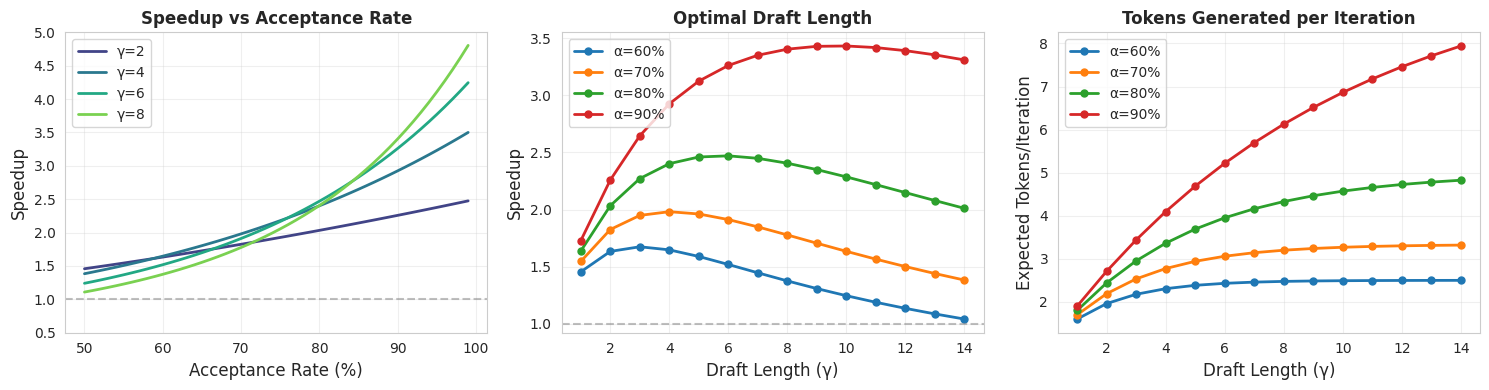


Optimal configurations (c=0.1):
--------------------------------------------------
α=60%: optimal γ=3, speedup=1.67×, tokens/iter=2.2
α=70%: optimal γ=4, speedup=1.98×, tokens/iter=2.8
α=80%: optimal γ=6, speedup=2.47×, tokens/iter=4.0
α=90%: optimal γ=10, speedup=3.43×, tokens/iter=6.9
α=95%: optimal γ=14, speedup=4.47×, tokens/iter=10.7


In [10]:
def expected_tokens_per_iteration(alpha, gamma):
    """
    Expected number of tokens generated per speculative iteration.
    
    Args:
        alpha: Acceptance rate
        gamma: Number of draft tokens
    
    Returns:
        Expected tokens (including the correction/bonus token)
    """
    if alpha == 1.0:
        return gamma + 1
    return (1 - alpha**(gamma + 1)) / (1 - alpha)

def theoretical_speedup(alpha, gamma, c=0.1):
    """
    Theoretical speedup from speculative decoding.
    
    Args:
        alpha: Acceptance rate
        gamma: Number of draft tokens
        c: Draft model cost relative to target (typically 0.05-0.2)
    """
    tokens = expected_tokens_per_iteration(alpha, gamma)
    # Cost = 1 target call + gamma draft calls (each costs c)
    cost = 1 + c * gamma
    return tokens / cost

# Analyze speedup for different parameters
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Left: Speedup vs acceptance rate for different gamma
ax1 = axes[0]
alphas = np.linspace(0.5, 0.99, 50)
gammas = [2, 4, 6, 8]
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(gammas)))

for gamma, color in zip(gammas, colors):
    speedups = [theoretical_speedup(a, gamma, c=0.1) for a in alphas]
    ax1.plot(alphas * 100, speedups, label=f'γ={gamma}', linewidth=2, color=color)

ax1.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Acceptance Rate (%)', fontsize=12)
ax1.set_ylabel('Speedup', fontsize=12)
ax1.set_title('Speedup vs Acceptance Rate', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0.5, 5)

# Middle: Optimal gamma for different acceptance rates
ax2 = axes[1]
alphas_test = [0.6, 0.7, 0.8, 0.9]
gammas_range = range(1, 15)

for alpha in alphas_test:
    speedups = [theoretical_speedup(alpha, g, c=0.1) for g in gammas_range]
    ax2.plot(list(gammas_range), speedups, 'o-', label=f'α={alpha:.0%}', linewidth=2, markersize=5)

ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('Draft Length (γ)', fontsize=12)
ax2.set_ylabel('Speedup', fontsize=12)
ax2.set_title('Optimal Draft Length', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Right: Expected tokens per iteration
ax3 = axes[2]
for alpha in alphas_test:
    tokens = [expected_tokens_per_iteration(alpha, g) for g in gammas_range]
    ax3.plot(list(gammas_range), tokens, 'o-', label=f'α={alpha:.0%}', linewidth=2, markersize=5)

ax3.set_xlabel('Draft Length (γ)', fontsize=12)
ax3.set_ylabel('Expected Tokens/Iteration', fontsize=12)
ax3.set_title('Tokens Generated per Iteration', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print optimal configurations
print("\nOptimal configurations (c=0.1):")
print("-" * 50)
for alpha in [0.6, 0.7, 0.8, 0.9, 0.95]:
    best_gamma = max(range(1, 15), key=lambda g: theoretical_speedup(alpha, g, 0.1))
    best_speedup = theoretical_speedup(alpha, best_gamma, 0.1)
    tokens_per_iter = expected_tokens_per_iteration(alpha, best_gamma)
    print(f"α={alpha:.0%}: optimal γ={best_gamma}, speedup={best_speedup:.2f}×, tokens/iter={tokens_per_iter:.1f}")


## Part 6: Draft Model Selection Strategies

### What Makes a Good Draft Model?

The draft model should:
1. **Be fast**: Small enough to generate quickly (10-20× smaller than target)
2. **Approximate target well**: High acceptance rate on typical inputs
3. **Have same vocabulary**: Must use identical tokenization

### Common Strategies

| Strategy | Example | Pros | Cons |
|----------|---------|------|------|
| **Smaller model from same family** | LLaMA-7B drafts for LLaMA-70B | Well-aligned distributions | Need separate model |
| **Distilled model** | Distilled version of target | Trained to match target | Training cost |
| **Early exit** | Use first N layers of target | Same model, no extra memory | Requires architecture support |
| **Quantized target** | INT4 version of target | Good alignment | Still large |


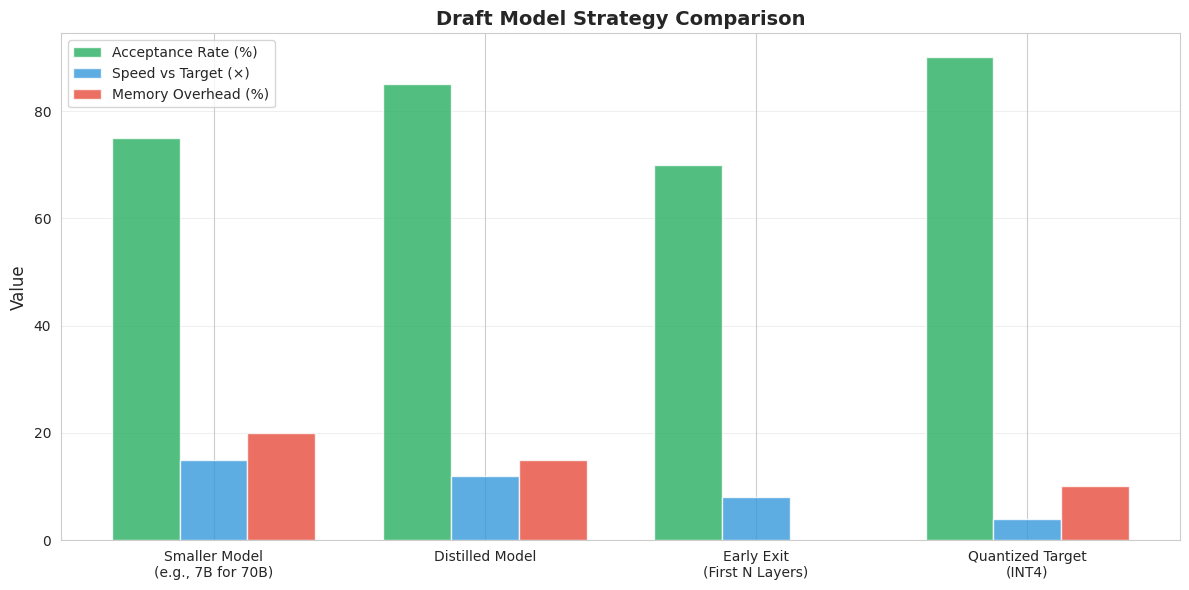


Theoretical speedups (γ=4):
------------------------------------------------------------
Smaller Model (e.g., 7B for 70B)    α=75%, c=0.07 → 2.41× speedup
Distilled Model                     α=85%, c=0.08 → 2.78× speedup
Early Exit (First N Layers)         α=70%, c=0.12 → 1.85× speedup
Quantized Target (INT4)             α=90%, c=0.25 → 2.05× speedup


In [11]:
# Visualize different draft model strategies
fig, ax = plt.subplots(figsize=(12, 6))

strategies = [
    'Smaller Model\n(e.g., 7B for 70B)',
    'Distilled Model',
    'Early Exit\n(First N Layers)',
    'Quantized Target\n(INT4)'
]

# Estimated metrics (illustrative)
acceptance_rates = [0.75, 0.85, 0.70, 0.90]
relative_speeds = [15, 12, 8, 4]  # How much faster than target
memory_overhead = [20, 15, 0, 10]  # % extra memory

x = np.arange(len(strategies))
width = 0.25

bars1 = ax.bar(x - width, [a * 100 for a in acceptance_rates], width, 
               label='Acceptance Rate (%)', color='#27ae60', alpha=0.8)
bars2 = ax.bar(x, relative_speeds, width, 
               label='Speed vs Target (×)', color='#3498db', alpha=0.8)
bars3 = ax.bar(x + width, memory_overhead, width, 
               label='Memory Overhead (%)', color='#e74c3c', alpha=0.8)

ax.set_ylabel('Value', fontsize=12)
ax.set_title('Draft Model Strategy Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(strategies, fontsize=10)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Calculate theoretical speedups
print("\nTheoretical speedups (γ=4):")
print("-" * 60)
for strat, alpha, speed in zip(strategies, acceptance_rates, relative_speeds):
    c = 1 / speed  # Draft cost relative to target
    speedup = theoretical_speedup(alpha, gamma=4, c=c)
    strat_clean = strat.replace('\n', ' ')
    print(f"{strat_clean:<35} α={alpha:.0%}, c={c:.2f} → {speedup:.2f}× speedup")


## Part 7: Connection to Other Techniques

### Speculative Decoding + KV Caching

Speculative decoding works well with KV caching:
- Both models maintain their own KV cache
- On rejection, roll back the cache to the last accepted position
- Prefill phase benefits both models

### Speculative Decoding + Batching

Can be combined with batched inference:
- Each sequence in batch has its own draft proposals
- Verification is still parallel within each sequence
- Different sequences may have different acceptance rates

### Relationship to Medusa and Tree Decoding

| Technique | Draft Source | Structure |
|-----------|--------------|----------|
| **Speculative Decoding** | Separate draft model | Linear chain |
| **Medusa** | Additional heads on target | Multiple branches |
| **Tree Decoding** | Draft model | Tree of candidates |


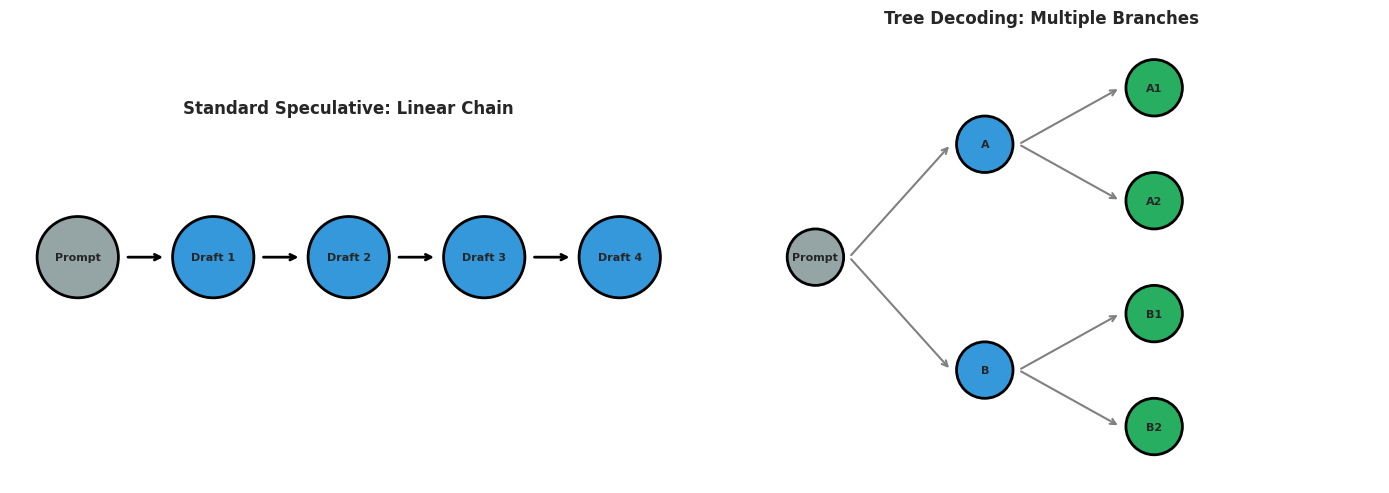

Tree decoding explores multiple draft continuations in parallel
This increases the chance of finding an accepted path!


In [12]:
# Visualize tree decoding extension
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Standard speculative (linear chain)
ax1 = axes[0]
ax1.set_xlim(-0.5, 4.5)
ax1.set_ylim(-0.5, 1.5)

# Draw linear chain
for i in range(5):
    color = '#95a5a6' if i == 0 else '#3498db'
    circle = plt.Circle((i, 0.5), 0.3, color=color, ec='black', linewidth=2)
    ax1.add_patch(circle)
    label = 'Prompt' if i == 0 else f'Draft {i}'
    ax1.text(i, 0.5, label, ha='center', va='center', fontsize=8, fontweight='bold')
    if i > 0:
        ax1.annotate('', xy=(i-0.35, 0.5), xytext=(i-0.65, 0.5),
                    arrowprops=dict(arrowstyle='->', color='black', lw=2))

ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title('Standard Speculative: Linear Chain', fontsize=12, fontweight='bold')

# Right: Tree decoding
ax2 = axes[1]
ax2.set_xlim(-1, 5)
ax2.set_ylim(-1, 3)

# Draw tree structure
nodes = [
    (0, 1, 'Prompt', '#95a5a6'),
    (1.5, 2, 'A', '#3498db'),
    (1.5, 0, 'B', '#3498db'),
    (3, 2.5, 'A1', '#27ae60'),
    (3, 1.5, 'A2', '#27ae60'),
    (3, 0.5, 'B1', '#27ae60'),
    (3, -0.5, 'B2', '#27ae60'),
]

edges = [
    (0, 1, 1.5, 2),
    (0, 1, 1.5, 0),
    (1.5, 2, 3, 2.5),
    (1.5, 2, 3, 1.5),
    (1.5, 0, 3, 0.5),
    (1.5, 0, 3, -0.5),
]

for x1, y1, x2, y2 in edges:
    ax2.annotate('', xy=(x2-0.3, y2), xytext=(x1+0.3, y1),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

for x, y, label, color in nodes:
    circle = plt.Circle((x, y), 0.25, color=color, ec='black', linewidth=2)
    ax2.add_patch(circle)
    ax2.text(x, y, label, ha='center', va='center', fontsize=8, fontweight='bold')

ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title('Tree Decoding: Multiple Branches', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("Tree decoding explores multiple draft continuations in parallel")
print("This increases the chance of finding an accepted path!")


## Part 8: Practical Considerations

### When Does Speculative Decoding Help?

| Scenario | Effectiveness |
|----------|---------------|
| Single request, large model | ✓✓✓ Excellent (memory-bound) |
| Batched inference | ✓✓ Good (if batch size is small) |
| Small models | ✓ Limited (may already be compute-bound) |
| Very low acceptance rate | ✗ Can hurt (draft overhead > savings) |

### Implementation Tips

1. **Tune γ (draft length)**: Start with 4-5, adjust based on acceptance rate
2. **Monitor acceptance rate**: If < 50%, consider a better draft model
3. **Handle edge cases**: Rejection at first token, end-of-sequence tokens
4. **Cache management**: Efficiently roll back KV cache on rejection


In [13]:
# Benchmark with different gamma values
print("Benchmarking different gamma values:")
print("=" * 60)

prompt = torch.randint(0, vocab_size, (1, 20)).to(device)
max_new_tokens = 100

results = []
for gamma in [2, 4, 6, 8]:
    times = []
    accept_rates = []
    target_calls_list = []
    
    for _ in range(5):  # Average over 5 runs
        start = time.time()
        _, stats = speculative_decode(target_model, draft_model, prompt, max_new_tokens, gamma=gamma)
        times.append(time.time() - start)
        accept_rates.append(stats['acceptance_rate'])
        target_calls_list.append(stats['n_target_calls'])
    
    avg_time = np.mean(times) * 1000
    avg_accept = np.mean(accept_rates)
    avg_target_calls = np.mean(target_calls_list)
    
    results.append({
        'gamma': gamma,
        'time_ms': avg_time,
        'acceptance_rate': avg_accept,
        'target_calls': avg_target_calls
    })
    
    print(f"γ={gamma}: {avg_time:.1f}ms, accept={avg_accept*100:.1f}%, target_calls={avg_target_calls:.0f}")

# Compare to standard
start = time.time()
_ = standard_generate(target_model, prompt, max_new_tokens)
standard_time = (time.time() - start) * 1000

print(f"\nStandard generation: {standard_time:.1f}ms")
print("\nSpeedups:")
for r in results:
    speedup = standard_time / r['time_ms']
    print(f"  γ={r['gamma']}: {speedup:.2f}×")


Benchmarking different gamma values:
γ=2: 157.2ms, accept=61.5%, target_calls=45
γ=4: 192.6ms, accept=42.9%, target_calls=37
γ=6: 227.5ms, accept=35.9%, target_calls=32
γ=8: 294.1ms, accept=25.6%, target_calls=33

Standard generation: 148.9ms

Speedups:
  γ=2: 0.95×
  γ=4: 0.77×
  γ=6: 0.65×
  γ=8: 0.51×


## Summary

### Key Takeaways

1. **The Problem**: Autoregressive LLM inference is slow because it's memory-bandwidth bound, generating one token at a time.

2. **Key Insight**: A model can **verify** K tokens as fast as **generating** 1 token, because both are limited by loading model weights from memory.

3. **Speculative Decoding Solution**:
   - Small draft model proposes K candidate tokens (fast)
   - Large target model verifies all K in one forward pass
   - Rejection sampling ensures output matches target distribution exactly

4. **Speedup Factors**:
   - Acceptance rate (α): How well draft approximates target
   - Draft length (γ): Number of speculative tokens
   - Draft overhead (c): Relative cost of draft model

5. **Typical Speedups**: 2-3× for well-matched draft/target pairs

6. **Best Practices**:
   - Choose draft from same model family (e.g., LLaMA-7B for LLaMA-70B)
   - Tune γ based on observed acceptance rate
   - Combine with KV caching for maximum efficiency

### Further Reading

- [Fast Inference from Transformers via Speculative Decoding](https://arxiv.org/abs/2211.17192) (Leviathan et al., 2023)
- [Accelerating Large Language Model Decoding with Speculative Sampling](https://arxiv.org/abs/2302.01318) (Chen et al., 2023)
- [Medusa: Simple Framework for Accelerating LLM Generation](https://arxiv.org/abs/2401.10774) (Cai et al., 2024)
- [SpecInfer: Accelerating Generative LLM Serving with Speculative Inference](https://arxiv.org/abs/2305.09781) (Miao et al., 2023)


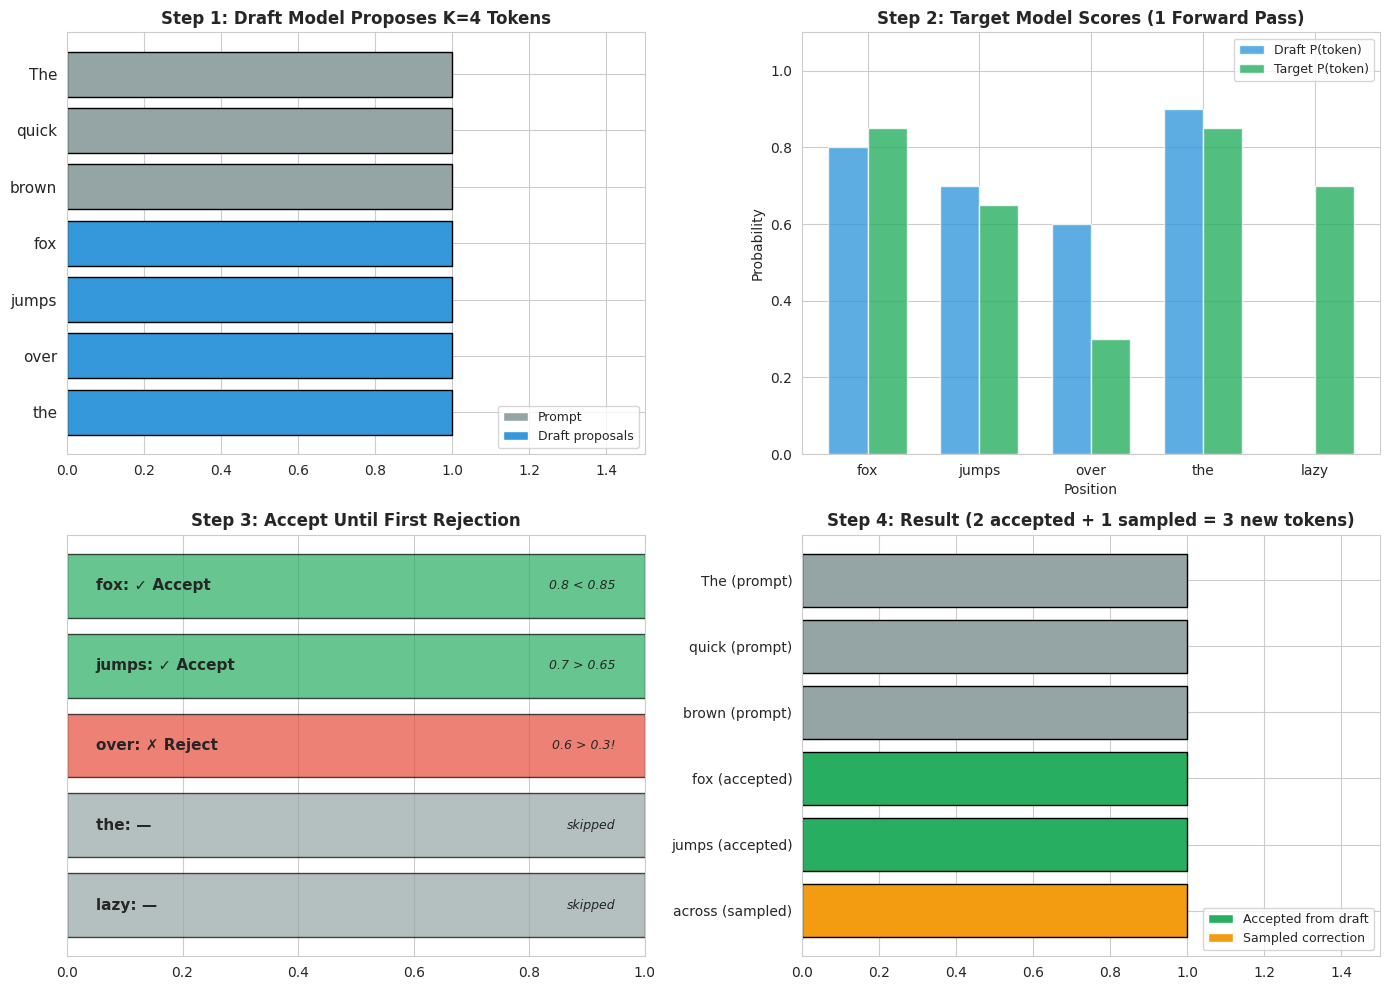

Result: Generated 3 new tokens with just 1 target model forward pass!
(Plus cheap draft model calls)


In [14]:
# Visualize the speculative decoding algorithm
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Step 1: Draft model generates candidates
ax1 = axes[0, 0]
prompt_tokens = ['The', 'quick', 'brown']
draft_tokens = ['fox', 'jumps', 'over', 'the']

all_tokens = prompt_tokens + draft_tokens
colors = ['#95a5a6'] * len(prompt_tokens) + ['#3498db'] * len(draft_tokens)

bars = ax1.barh(range(len(all_tokens)), [1]*len(all_tokens), color=colors, edgecolor='black')
ax1.set_yticks(range(len(all_tokens)))
ax1.set_yticklabels(all_tokens, fontsize=11)
ax1.set_xlim(0, 1.5)
ax1.set_title('Step 1: Draft Model Proposes K=4 Tokens', fontsize=12, fontweight='bold')
ax1.set_xlabel('', fontsize=10)
ax1.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#95a5a6', label='Prompt'),
                   Patch(facecolor='#3498db', label='Draft proposals')]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=9)

# Step 2: Target model verifies
ax2 = axes[0, 1]
# Target model processes all tokens at once and outputs probabilities
positions = ['fox', 'jumps', 'over', 'the', 'lazy']
draft_probs = [0.8, 0.7, 0.6, 0.9, None]  # Probability assigned to draft tokens
target_probs = [0.85, 0.65, 0.3, 0.85, 0.7]  # Target model probabilities

x = np.arange(len(positions))
width = 0.35

# Only show first 4 for draft (no prediction for position 5)
bars1 = ax2.bar(x[:4] - width/2, draft_probs[:4], width, label='Draft P(token)', color='#3498db', alpha=0.8)
bars2 = ax2.bar(x - width/2 + width, target_probs, width, label='Target P(token)', color='#27ae60', alpha=0.8)

ax2.set_xlabel('Position', fontsize=10)
ax2.set_ylabel('Probability', fontsize=10)
ax2.set_title('Step 2: Target Model Scores (1 Forward Pass)', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(positions, fontsize=10)
ax2.legend(fontsize=9)
ax2.set_ylim(0, 1.1)

# Step 3: Accept/Reject
ax3 = axes[1, 0]
accept_status = ['✓ Accept', '✓ Accept', '✗ Reject', '—', '—']
accept_colors = ['#27ae60', '#27ae60', '#e74c3c', '#95a5a6', '#95a5a6']
accept_reasons = ['0.8 < 0.85', '0.7 > 0.65', '0.6 > 0.3!', 'skipped', 'skipped']

for i, (token, status, color, reason) in enumerate(zip(positions, accept_status, accept_colors, accept_reasons)):
    ax3.barh(i, 1, color=color, edgecolor='black', alpha=0.7)
    ax3.text(0.05, i, f'{token}: {status}', va='center', fontsize=11, fontweight='bold')
    ax3.text(0.95, i, reason, va='center', ha='right', fontsize=9, style='italic')

ax3.set_xlim(0, 1)
ax3.set_yticks([])
ax3.set_title('Step 3: Accept Until First Rejection', fontsize=12, fontweight='bold')
ax3.invert_yaxis()

# Step 4: Sample correction
ax4 = axes[1, 1]
result_tokens = ['The', 'quick', 'brown', 'fox', 'jumps', 'across']
result_colors = ['#95a5a6'] * 3 + ['#27ae60'] * 2 + ['#f39c12']
result_labels = ['prompt', 'prompt', 'prompt', 'accepted', 'accepted', 'sampled']

bars = ax4.barh(range(len(result_tokens)), [1]*len(result_tokens), color=result_colors, edgecolor='black')
ax4.set_yticks(range(len(result_tokens)))
ax4.set_yticklabels([f'{t} ({l})' for t, l in zip(result_tokens, result_labels)], fontsize=10)
ax4.set_xlim(0, 1.5)
ax4.set_title('Step 4: Result (2 accepted + 1 sampled = 3 new tokens)', fontsize=12, fontweight='bold')
ax4.invert_yaxis()

legend_elements = [Patch(facecolor='#27ae60', label='Accepted from draft'),
                   Patch(facecolor='#f39c12', label='Sampled correction')]
ax4.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

print("Result: Generated 3 new tokens with just 1 target model forward pass!")
print("(Plus cheap draft model calls)")
